In [3]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['image.origin'] = 'lower'  
plt.style.use('dark_background') 
from astropy import units as u
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.models import Gaussian1D, Linear1D
from astropy.modeling.fitting import LinearLSQFitter
from IPython.display import Image
# astroquery provides an interface to the NIST atomic line database
from astroquery.nist import Nist 

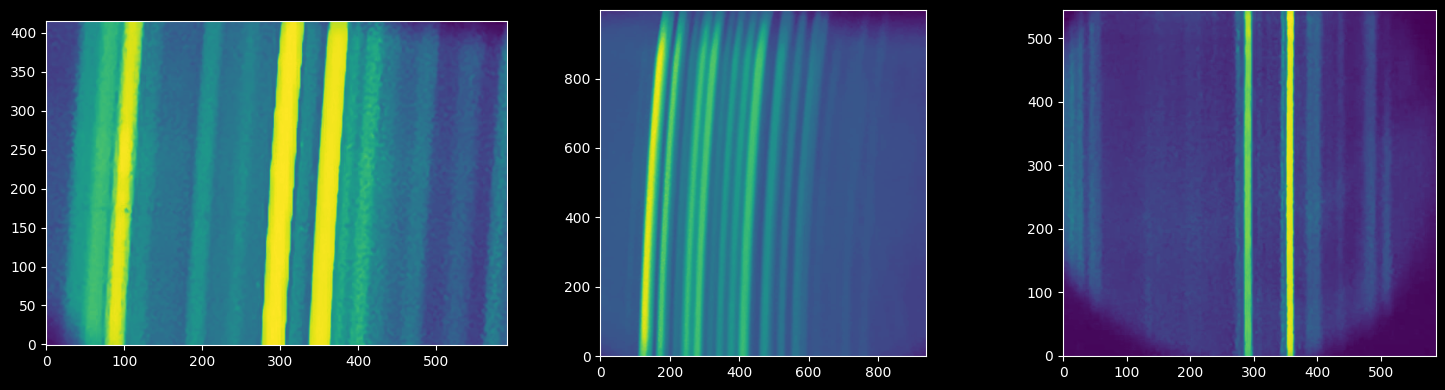

In [2]:
kr_filenameu = "Kripton.jpeg"
hg_filenameu = "Mercurio.jpeg"
ne_filenameu = "Neon.jpeg"

kr_imageu = np.array(PILImage.open(kr_filenameu).convert("L"))
hg_imageu = np.array(PILImage.open(hg_filenameu).convert("L"))
ne_imageu = np.array(PILImage.open(ne_filenameu).convert("L"))
fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.imshow(hg_imageu);
kr.imshow(kr_imageu);
ne.imshow(ne_imageu);
plt.tight_layout()
plt.show()


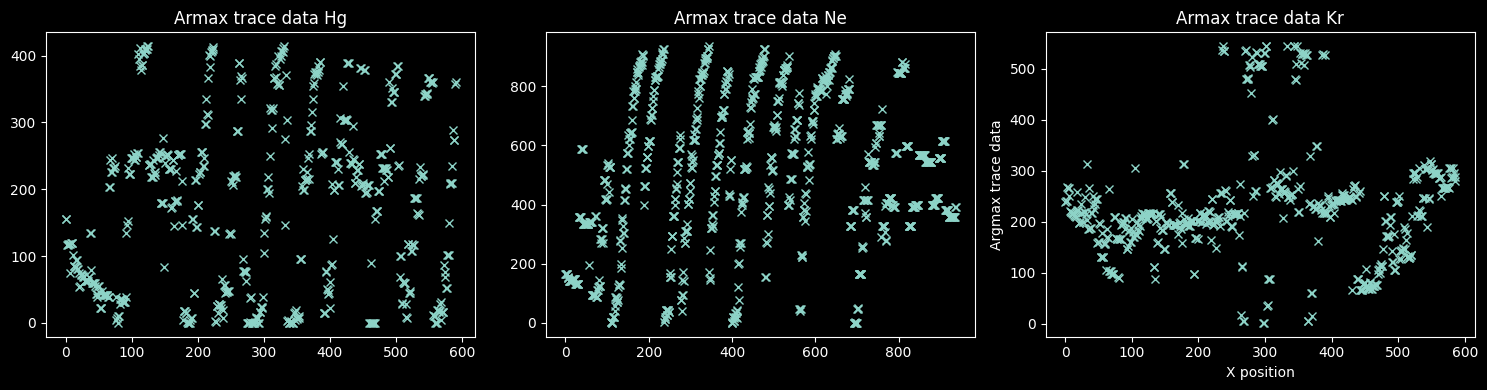

In [16]:
yvals = np.argmax(kr_imageu, axis=0)
xvals = np.arange(kr_imageu.shape[1])

yvals2 = np.argmax(hg_imageu, axis=0)
xvals2 = np.arange(hg_imageu.shape[1])

yvals3 = np.argmax(ne_imageu, axis=0)
xvals3 = np.arange(ne_imageu.shape[1])

fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.plot(xvals2, yvals2, "x");

hg.set_title("Armax trace data Hg");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

kr.plot(xvals, yvals, "x");

kr.set_title("Armax trace data Kr");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");


ne.plot(xvals3, yvals3, 'x');

ne.set_title("Armax trace data Ne");

plt.ylabel("Argmax trace data")
plt.xlabel("X position");
plt.tight_layout()
plt.show()


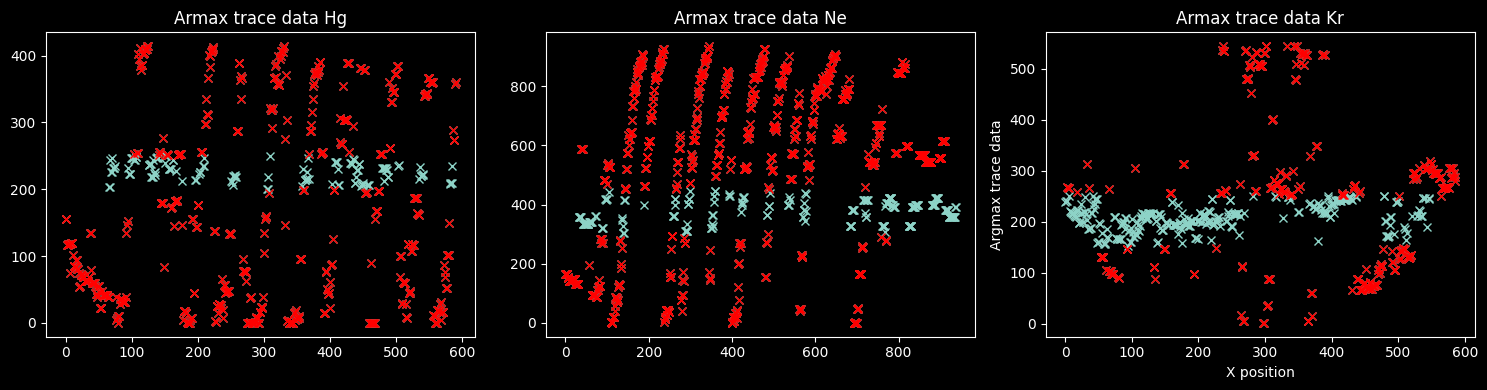

In [19]:
bad_pixelsKr = (yvals < 150) | (yvals > 250)
bad_pixelsNe = (yvals3 < 300) | (yvals3 > 450)
bad_pixelsHg = (yvals2 < 200) | (yvals2 > 250)

fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.plot(xvals2, yvals2, "x");
hg.plot(xvals2[bad_pixelsHg], yvals2[bad_pixelsHg], 'rx')
hg.set_title("Armax trace data Hg");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

kr.plot(xvals, yvals, "x");
kr.plot(xvals[bad_pixelsKr], yvals[bad_pixelsKr], 'rx')
kr.set_title("Armax trace data Kr");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");


ne.plot(xvals3, yvals3, 'x');
ne.plot(xvals3[bad_pixelsNe], yvals3[bad_pixelsNe], 'rx')

ne.set_title("Armax trace data Ne");

plt.ylabel("Argmax trace data")
plt.xlabel("X position");
plt.tight_layout()
plt.show()


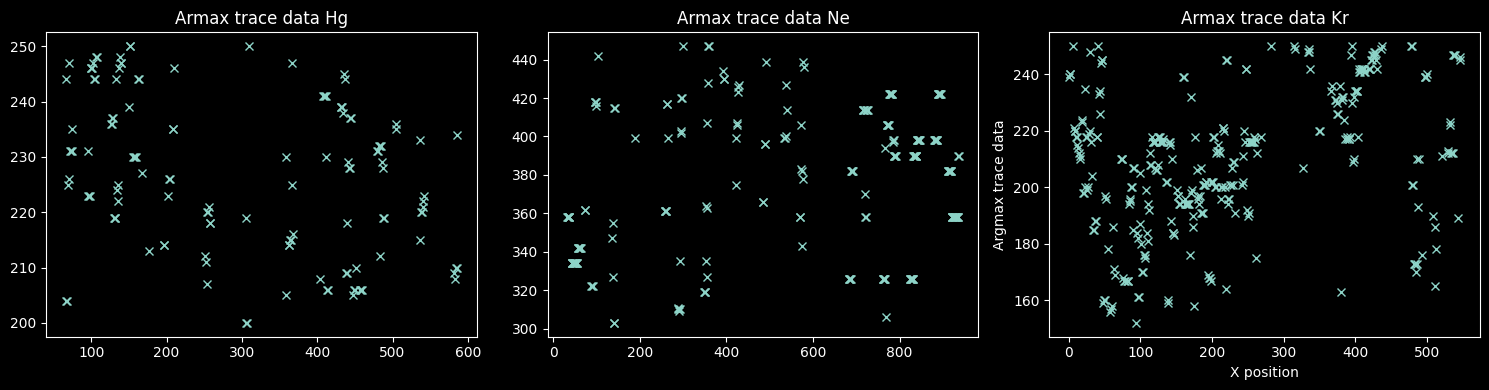

In [22]:
fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.plot(xvals2[~bad_pixelsHg], yvals2[~bad_pixelsHg], 'x')
hg.set_title("Armax trace data Hg");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");


kr.plot(xvals[~bad_pixelsKr], yvals[~bad_pixelsKr], 'x')
kr.set_title("Armax trace data Kr");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");



ne.plot(xvals3[~bad_pixelsNe], yvals3[~bad_pixelsNe], 'x')
ne.set_title("Armax trace data Ne");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

plt.tight_layout()
plt.show()

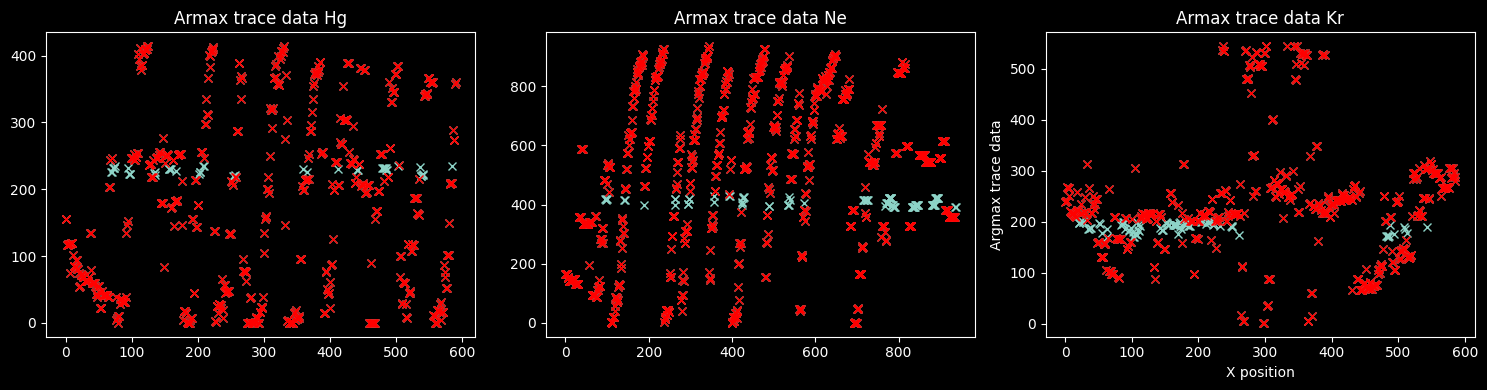

In [23]:
bad_pixelsKr2 = (yvals < 170) | (yvals > 200)
bad_pixelsNe2 = (yvals3 < 390) | (yvals3 > 430)
bad_pixelsHg2 = (yvals2 < 220) | (yvals2 > 235)

fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.plot(xvals2, yvals2, "x");
hg.plot(xvals2[bad_pixelsHg2], yvals2[bad_pixelsHg2], 'rx')
hg.set_title("Armax trace data Hg");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

kr.plot(xvals, yvals, "x");
kr.plot(xvals[bad_pixelsKr2], yvals[bad_pixelsKr2], 'rx')
kr.set_title("Armax trace data Kr");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");


ne.plot(xvals3, yvals3, 'x');
ne.plot(xvals3[bad_pixelsNe2], yvals3[bad_pixelsNe2], 'rx')

ne.set_title("Armax trace data Ne");

plt.ylabel("Argmax trace data")
plt.xlabel("X position");
plt.tight_layout()
plt.show()


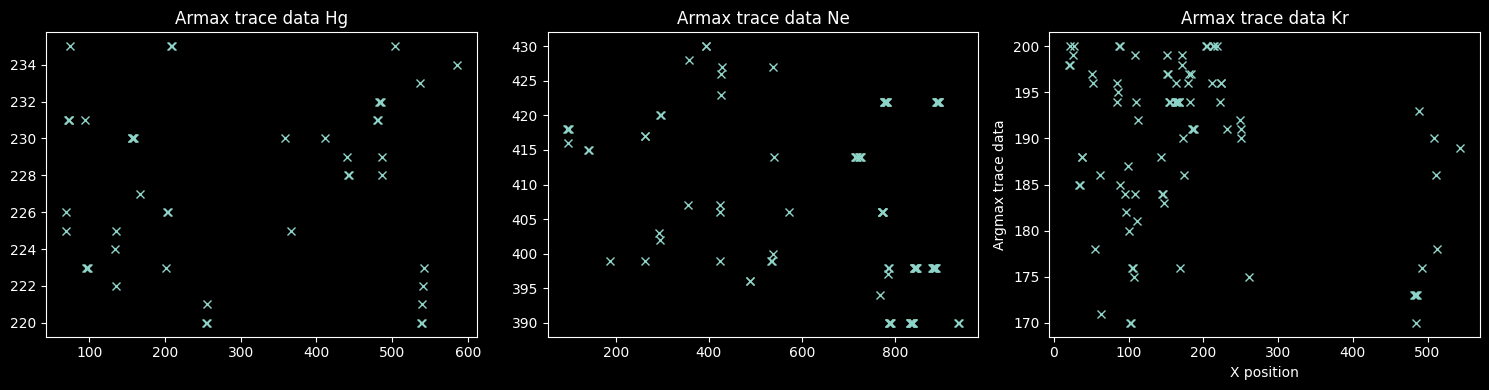

In [26]:
fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.plot(xvals2[~bad_pixelsHg2], yvals2[~bad_pixelsHg2], 'x')
hg.set_title("Armax trace data Hg");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");


kr.plot(xvals[~bad_pixelsKr2], yvals[~bad_pixelsKr2], 'x')
kr.set_title("Armax trace data Kr");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");



ne.plot(xvals3[~bad_pixelsNe2], yvals3[~bad_pixelsNe2], 'x')
ne.set_title("Armax trace data Ne");
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

plt.tight_layout()
plt.show()

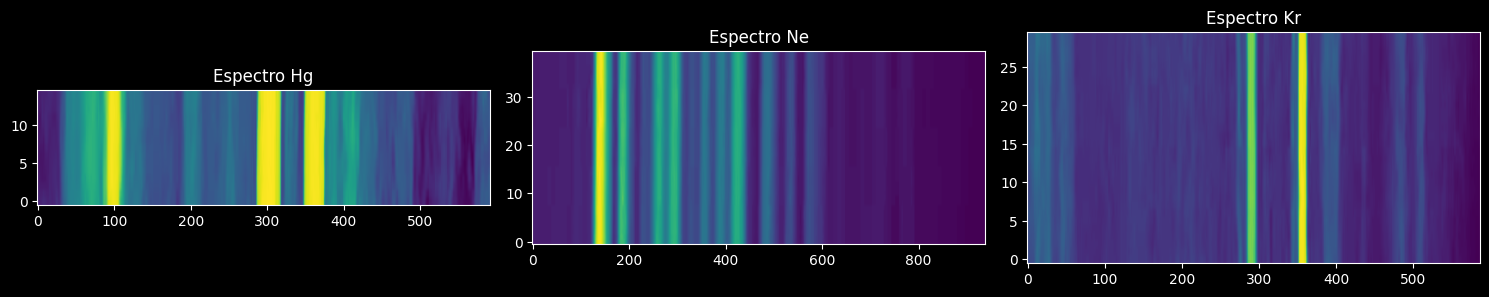

In [51]:
fig, (hg, ne, kr) = plt.subplots(1, 3, figsize=(15, 4)) 
hg.imshow(hg_imageu[220: 235, :],aspect=10);
hg.set_title("Espectro Hg")

kr.imshow(kr_imageu[170:200, :],aspect=10);
kr.set_title("Espectro Kr")

ne.imshow(ne_imageu[390:430, :],aspect=10);
ne.set_title("Espectro Ne")


plt.tight_layout()
plt.show()


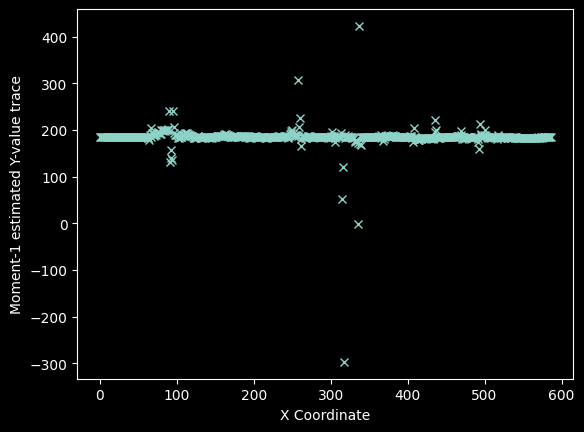

In [53]:




yaxiskr = np.repeat(np.arange(170, 200)[:,None],kr_imageu.shape[1], axis=1)
backgroundkr = np.median(kr_imageu)
weighted_yaxis_valueskr = np.average(yaxiskr, axis=0,weights=kr_imageu[170:200,:] - backgroundkr)
plt.plot(xvals, weighted_yaxis_valueskr, 'x')
plt.xlabel("X Coordinate")
plt.ylabel("Moment-1 estimated Y-value trace");







In [1]:
hgu_spectrum = np.array([np.average(hg_imageu[int(yaxishg)-npixels_to_cut:int(yaxishg)+npixels_to_cut, ii],
                                weights=model_trace_profilehg)
                     for yaxishg , ii in zip(trace_centerhg, xaxishg)])

NameError: name 'np' is not defined

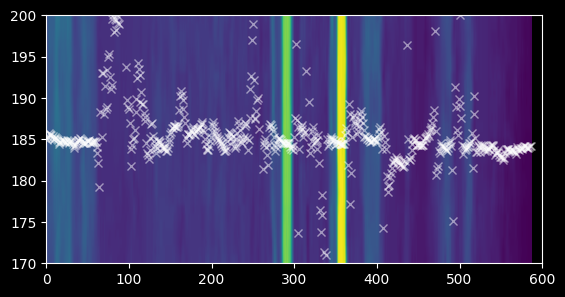

In [55]:
plt.imshow(kr_imageu[170:200,:],
          extent=[0,kr_imageu.shape[1],170,200])
plt.gca().set_aspect(10) # we stretch the image out by 10x in the y-direction
plt.plot(xvals, weighted_yaxis_valueskr, 'wx', alpha=0.5)
plt.axis((0,600,170,200));

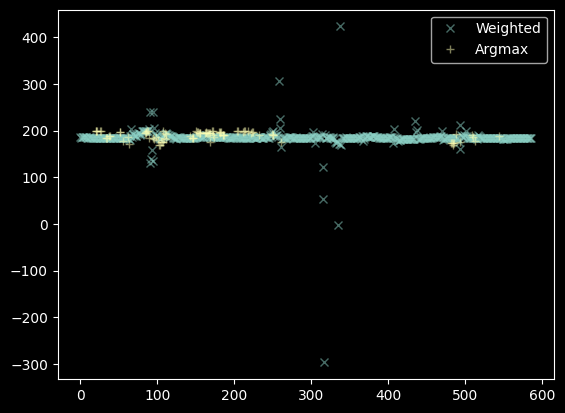

In [56]:
plt.plot(xvals, weighted_yaxis_valueskr, 'x', label="Weighted", alpha=0.5)
plt.plot(xvals[~bad_pixelsKr2], yvals[~bad_pixelsKr2], '+', label="Argmax", alpha=0.5)
plt.legend(loc='best');

In [57]:
bad_moments = (weighted_yaxis_valueskr > 210) | (weighted_yaxis_valueskr < 150)

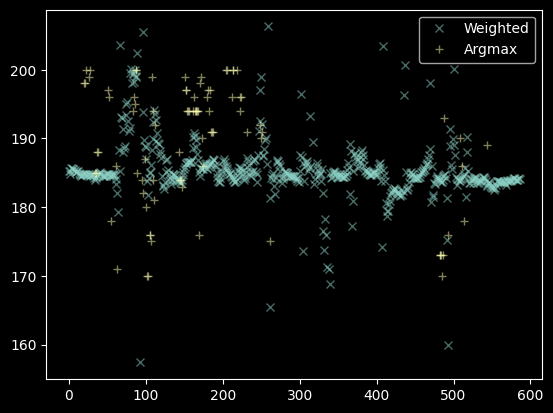

In [58]:
plt.plot(xvals[~bad_moments], weighted_yaxis_valueskr[~bad_moments], 'x', label="Weighted", alpha=0.5)
plt.plot(xvals[~bad_pixelsKr2], yvals[~bad_pixelsKr2], '+', label="Argmax", alpha=0.5)
plt.legend(loc='best');

In [63]:
polymodel = Polynomial1D(degree=3)
linfitter = LinearLSQFitter()
fitted_polymodelkr = linfitter(polymodel, xvals[~bad_moments], weighted_yaxis_valueskr[~bad_moments])

In [64]:
fitted_polymodelkr

<Polynomial1D(3, c0=186.0839624, c1=0.01790568, c2=-0.00010369, c3=0.00000012)>

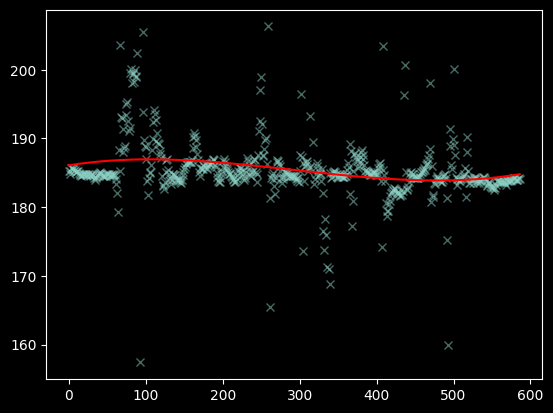

In [65]:
plt.plot(xvals[~bad_moments], weighted_yaxis_valueskr[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodelkr(xvals), color='r');

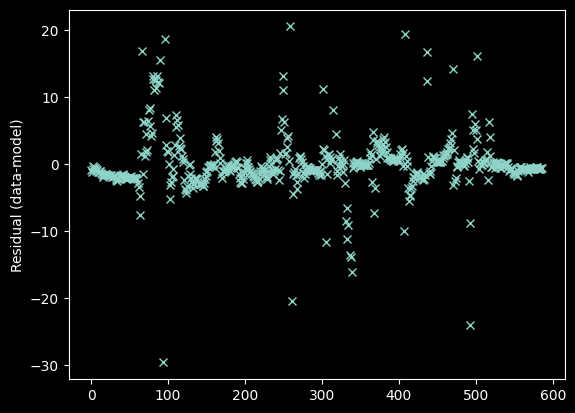

In [66]:
plt.plot(xvals[~bad_moments],
        weighted_yaxis_valueskr[~bad_moments] - fitted_polymodelkr(xvals[~bad_moments]), 'x')
plt.ylabel("Residual (data-model)");

In [67]:
polymodel = Polynomial1D(degree=3)
fitted_polymodel = linfitter(polymodel, xvals[~bad_moments], weighted_yaxis_valueskr[~bad_moments])
fitted_polymodel

<Polynomial1D(3, c0=186.0839624, c1=0.01790568, c2=-0.00010369, c3=0.00000012)>

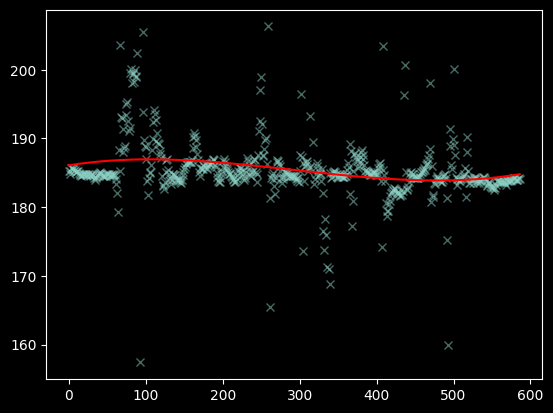

In [69]:
plt.plot(xvals[~bad_moments], weighted_yaxis_valueskr[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

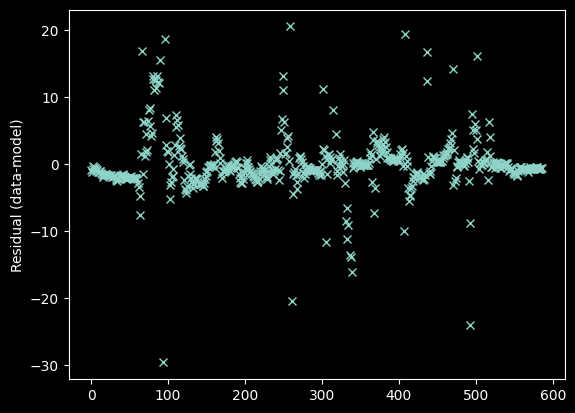

In [70]:
plt.plot(xvals[~bad_moments],
      weighted_yaxis_valueskr[~bad_moments] - fitted_polymodel(xvals[~bad_moments]), 'x')
plt.ylabel("Residual (data-model)");

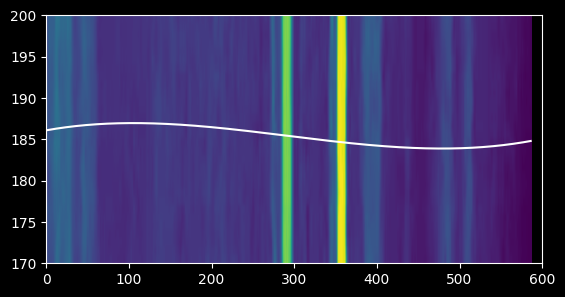

In [72]:
plt.imshow(kr_imageu[170:200,:],
          extent=[0,kr_imageu.shape[1],170,200])
plt.gca().set_aspect(10);
plt.plot(xvals, fitted_polymodel(xvals), 'w')
plt.axis((0,600,170,200));

In [73]:
polymodel = Polynomial1D(degree=3)
fitted_polymodel = linfitter(polymodel, xvals[(~bad_moments) & (xvals < 500)],
                             weighted_yaxis_valueskr[(~bad_moments) & (xvals < 500)])
fitted_polymodel

<Polynomial1D(3, c0=185.33577775, c1=0.03886465, c2=-0.00021942, c3=0.00000028)>

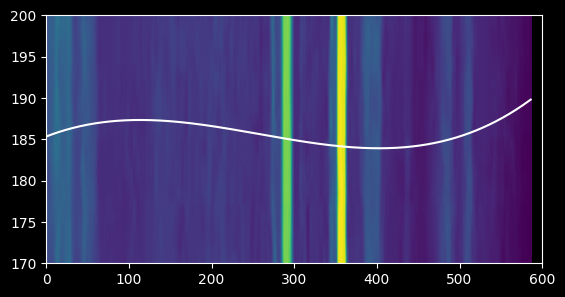

In [74]:
plt.imshow(kr_imageu[170:200,:],
          extent=[0,kr_imageu.shape[1],170,200])
plt.gca().set_aspect(10);
plt.plot(xvals, fitted_polymodel(xvals), 'w')
plt.axis((0,600,170,200));

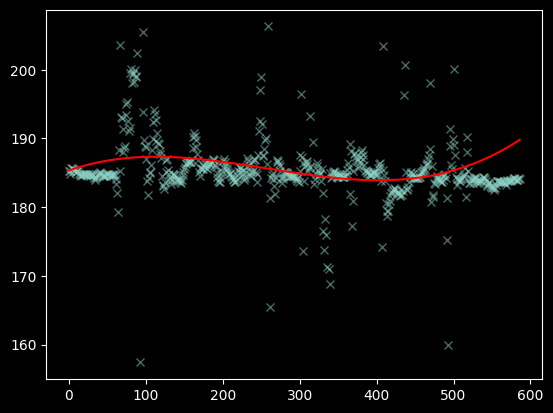

In [75]:
plt.plot(xvals[~bad_moments], weighted_yaxis_valueskr[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

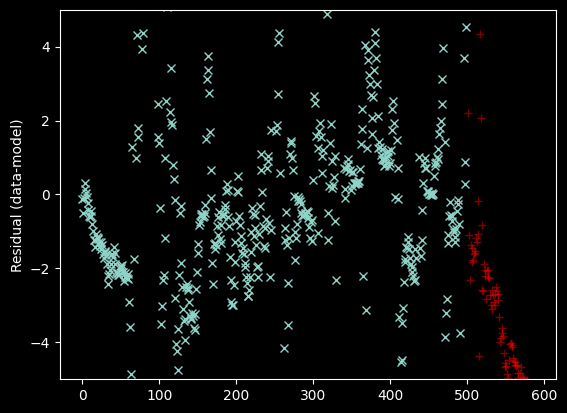

In [77]:
plt.plot(xvals[~bad_moments & (xvals < 500)],
        weighted_yaxis_valueskr[~bad_moments & (xvals < 500)] - fitted_polymodel(xvals[~bad_moments & (xvals < 500)]), 'x')
plt.plot(xvals[~bad_moments & (xvals > 500)],
        weighted_yaxis_valueskr[~bad_moments & (xvals > 500)] - fitted_polymodel(xvals[~bad_moments & (xvals > 500)]), 'r+', alpha=0.5)
plt.ylim(-5, 5)
plt.ylabel("Residual (data-model)");

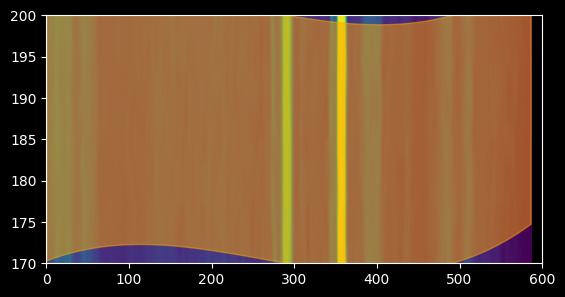

In [78]:
plt.imshow(kr_imageu[170:200,:],
          extent=[0,kr_imageu.shape[1],170,200])
plt.gca().set_aspect(10);
plt.fill_between(xvals, fitted_polymodel(xvals)-15,
                fitted_polymodel(xvals)+15,
                color='orange', alpha=0.5)
plt.axis((0,600,170,200));

In [4]:
#para kr_imageu
xvals5 = np.arange(kr_imageu.shape[1])
yaxis5 = np.repeat(np.arange(200,400)[:,None], kr_imageu.shape[1], axis=1)
weighted_yaxis_valueskru = np.average(yaxis5, axis=0, weights= kr_imageu[200:400, :]- np.median(kr_imageu))
polymodelkru= Polynomial1D(degree=2)
fitted_polymodel5 = linfitter(polymodelkru, xvals5, weighted_yaxis_valueskru)
trace_centerkr_imageu = fitted_polymodel5(xvals5)

#para ne_imageu
xvals6 = np.arange(ne_imageu.shape[1])
yaxis6 = np.repeat(np.arange(200,400)[:,None], ne_imageu.shape[1], axis=1)
weighted_yaxis_valuesneu = np.average(yaxis6, axis=0, weights= ne_imageu[200:400, :]- np.median(ne_imageu))
polymodelneu= Polynomial1D(degree=3)
fitted_polymodel6 = linfitter(polymodelneu, xvals6, weighted_yaxis_valuesneu)
trace_centerne_imageu = fitted_polymodel6(xvals6)



NameError: name 'kr_imageu' is not defined